# UAVDT Notebook 04 v2 — Metric Calibration and 3D Cuboids from GT BEV Tracks

This version is designed to run after **Notebook 03A** (`GT annotations → BEV tracks`). It avoids the previous state/order bug by defining defaults inside the cells that need them, and it searches for the GT-based `vehicle_tracks_bev.csv` first.

Expected inputs:
- Notebook 02 homography JSON in `work/notebook_02_bev_homography/`
- Notebook 03A tracks CSV in `work/notebook_03a_gt_annotations_bev_tracks/vehicle_tracks_bev.csv`

Outputs:
- `metric_calibration.json`
- `vehicle_tracks_metric.csv`
- `vehicle_cuboids_metric.csv`
- plots, OBJ, and dynamic scene JSON


In [1]:
#@title 1. Set local project paths
from pathlib import Path
import json
import math
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from notebook_local import resolve_project_dir, print_local_setup

PROJECT_DIR = resolve_project_dir()
WORK_DIR = PROJECT_DIR / 'work'
NB02_DIR = WORK_DIR / 'notebook_02_bev_homography'
NB02B_DIR = WORK_DIR / 'notebook_02b_visual_metric_homography'
NB03A_DIR = WORK_DIR / 'notebook_03a_gt_annotations_bev_tracks'
NB03_OLD_DIR = WORK_DIR / 'notebook_03_bev_vehicles'
NB04_DIR = WORK_DIR / 'notebook_04_metric_scene_export'
NB04_DIR.mkdir(parents=True, exist_ok=True)

print_local_setup(PROJECT_DIR)
print('Notebook 02 directory:', NB02_DIR)
print('Notebook 02B metric directory:', NB02B_DIR, 'exists:', NB02B_DIR.exists())
print('Notebook 03A directory:', NB03A_DIR)
print('Notebook 04 output directory:', NB04_DIR)

if not NB02_DIR.exists():
    raise FileNotFoundError('Notebook 02 output directory not found. Run Notebook 02 first: ' + str(NB02_DIR))
if not NB03A_DIR.exists():
    print('Warning: Notebook 03A output directory not found. Will try old Notebook 03 directory if needed.')


PROJECT_DIR: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project
DATASET_DIR: not found
Set DRONE3D_PROJECT_DIR and UAVDT_DATASET_DIR to override these defaults.
Notebook 02 directory: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02_bev_homography
Notebook 02B metric directory: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02b_visual_metric_homography exists: True
Notebook 03A directory: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks
Notebook 04 output directory: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export


In [2]:
#@title 2. Load homography/calibration
# Prefer Notebook 02B metric calibration when available. It maps image pixels directly
# to ground-plane meters and avoids the rough pixel-BEV scaling step from Notebook 02.
USE_02B_METRIC_HOMOGRAPHY = True #@param {type:'boolean'}

metric_calibration_candidates = []
if 'NB02B_DIR' in globals() and NB02B_DIR.exists():
    metric_calibration_candidates += [
        NB02B_DIR / 'metric_homography_calibration.json',
        NB02B_DIR / 'frame_00000_metric_homography.json',
    ]
    metric_calibration_candidates += sorted(NB02B_DIR.glob('*metric*homography*.json'))

metric_calibration_path = None
if USE_02B_METRIC_HOMOGRAPHY:
    for p in metric_calibration_candidates:
        if p.exists():
            metric_calibration_path = p
            break

USE_METRIC_HOMOGRAPHY = metric_calibration_path is not None

if USE_METRIC_HOMOGRAPHY:
    homography_path = metric_calibration_path
    with open(homography_path, 'r') as f:
        homography_data = json.load(f)
    print('Loaded Notebook 02B metric calibration:', homography_path)
    print('Calibration keys:', list(homography_data.keys()))

    if 'H_image_to_ground_m' not in homography_data:
        raise KeyError('02B calibration must contain H_image_to_ground_m.')

    H_image_to_ground_m = np.array(homography_data['H_image_to_ground_m'], dtype=np.float32)
    H_ground_m_to_image = np.array(homography_data.get('H_ground_m_to_image', np.linalg.inv(H_image_to_ground_m)), dtype=np.float32)
    H_image_to_bev = np.array(homography_data.get('H_image_to_bev_px', homography_data.get('H_image_to_bev', H_image_to_ground_m)), dtype=np.float32)
    BEV_WIDTH = int(homography_data.get('bev_preview_width_px', homography_data.get('bev_width', 800)))
    BEV_HEIGHT = int(homography_data.get('bev_preview_height_px', homography_data.get('bev_height', 1200)))
    ROAD_WIDTH_M = float(homography_data.get('road_width_m', 24.0))
    ROAD_LENGTH_M = float(homography_data.get('road_length_m', 90.0))
    pixels_per_meter = BEV_WIDTH / ROAD_WIDTH_M
    meters_per_pixel = 1.0 / pixels_per_meter
    print('Using direct metric coordinates from 02B.')
    print('Road metric size:', ROAD_WIDTH_M, 'x', ROAD_LENGTH_M, 'm')
    print('BEV preview size:', BEV_WIDTH, 'x', BEV_HEIGHT)
    print('H_image_to_ground_m:')
    print(H_image_to_ground_m)
else:
    homography_candidates = [
        NB02_DIR / 'homography_image_to_bev.json',
        NB02_DIR / 'bev_homography.json',
        NB02_DIR / 'homography.json',
    ]
    homography_candidates += sorted(NB02_DIR.glob('*homography*.json'))

    homography_path = None
    for p in homography_candidates:
        if p.exists():
            homography_path = p
            break

    if homography_path is None:
        print('JSON files found in Notebook 02 directory:')
        for p in sorted(NB02_DIR.glob('*.json')):
            print(' ', p)
        raise FileNotFoundError('Could not find a homography JSON file from Notebook 02.')

    with open(homography_path, 'r') as f:
        homography_data = json.load(f)

    print('Loaded Notebook 02 pixel homography JSON:', homography_path)
    print('Homography keys:', list(homography_data.keys()))

    if 'H_image_to_bev' in homography_data:
        H_image_to_bev = np.array(homography_data['H_image_to_bev'], dtype=np.float32)
    elif 'homography' in homography_data:
        H_image_to_bev = np.array(homography_data['homography'], dtype=np.float32)
    elif 'H' in homography_data:
        H_image_to_bev = np.array(homography_data['H'], dtype=np.float32)
    else:
        raise KeyError('Homography JSON does not contain H_image_to_bev, homography, or H.')

    BEV_WIDTH = int(homography_data.get('bev_width', homography_data.get('BEV_WIDTH', 600)))
    BEV_HEIGHT = int(homography_data.get('bev_height', homography_data.get('BEV_HEIGHT', 1000)))
    H_image_to_ground_m = None
    print('BEV size:', BEV_WIDTH, 'x', BEV_HEIGHT)
    print('H_image_to_bev:')
    print(H_image_to_bev)



Loaded Notebook 02B metric calibration: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02b_visual_metric_homography/metric_homography_calibration.json
Calibration keys: ['version', 'reference_frame_index', 'reference_frame_path', 'reference_frame_name', 'image_width_px', 'image_height_px', 'road_width_m', 'road_length_m', 'bev_preview_width_px', 'bev_preview_height_px', 'image_points_px', 'ground_points_m', 'active_calibration_point_ids', 'H_image_to_ground_m', 'H_ground_m_to_image', 'H_image_to_bev_px', 'coordinate_system', 'fit_error_m', 'outputs']
Using direct metric coordinates from 02B.
Road metric size: 24.0 x 90.0 m
BEV preview size: 800 x 1200
H_image_to_ground_m:
[[-2.1991639e-01 -4.1539761e-01  1.4873679e+02]
 [-7.7740159e-03  3.4057593e-01 -1.0238601e+02]
 [-3.8988816e-04 -2.8994925e-02  1.0000000e+00]]


In [3]:
#@title 3. Load GT-based BEV tracks from Notebook 03A
track_candidates = []
if NB03A_DIR.exists():
    track_candidates += [
        NB03A_DIR / 'vehicle_tracks_bev.csv',
        NB03A_DIR / 'vehicle_tracks_bev_gt.csv',
    ]
    track_candidates += sorted(NB03A_DIR.glob('*bev*.csv'))

# Fallback to old Notebook 03 only if GT-based tracks do not exist.
if NB03_OLD_DIR.exists():
    track_candidates += [
        NB03_OLD_DIR / 'vehicle_tracks_bev.csv',
        NB03_OLD_DIR / 'projected_vehicle_tracks.csv',
        NB03_OLD_DIR / 'detections_projected_bev.csv',
    ]
    track_candidates += sorted(NB03_OLD_DIR.glob('*bev*.csv'))

tracks_path = None
for p in track_candidates:
    if p.exists():
        tracks_path = p
        break

if tracks_path is None:
    print('Candidate track files checked:')
    for p in track_candidates:
        print(' ', p)
    raise FileNotFoundError('Could not find vehicle_tracks_bev.csv from Notebook 03A.')

tracks = pd.read_csv(tracks_path)

print('Loaded tracks CSV:', tracks_path)
print('Shape:', tracks.shape)
print('Columns:', tracks.columns.tolist())
display(tracks.head())

required_any = ['frame_id', 'frame_idx', 'sample_frame_idx']
if not any(c in tracks.columns for c in required_any):
    raise KeyError('Tracks must contain one of these frame columns: ' + str(required_any))
if 'track_id' not in tracks.columns:
    raise KeyError('Tracks must contain track_id. If this is a YOLO-only detections CSV, rerun Notebook 03A.')
if not all(c in tracks.columns for c in ['x1', 'y1', 'x2', 'y2']):
    raise KeyError('Tracks must contain x1, y1, x2, y2 bounding box columns.')

# Normalize frame_id.
if 'frame_id' not in tracks.columns:
    if 'frame_idx' in tracks.columns:
        tracks['frame_id'] = tracks['frame_idx'].astype(int)
    else:
        tracks['frame_id'] = tracks['sample_frame_idx'].astype(int)

# Add class name if missing.
if 'class_name' not in tracks.columns:
    tracks['class_name'] = 'vehicle'

# If BEV coordinates are missing, compute them from bbox bottom-center.
if not all(c in tracks.columns for c in ['bev_x_px', 'bev_y_px']):
    print('BEV coordinates not found. Computing them from bbox bottom-center using homography.')
    cx = 0.5 * (pd.to_numeric(tracks['x1'], errors='coerce') + pd.to_numeric(tracks['x2'], errors='coerce'))
    cy = pd.to_numeric(tracks['y2'], errors='coerce')
    pts = np.stack([cx.to_numpy(dtype=np.float32), cy.to_numpy(dtype=np.float32)], axis=1).reshape(-1, 1, 2)
    out = cv2.perspectiveTransform(pts, H_image_to_bev).reshape(-1, 2)
    tracks['bev_x_px'] = out[:, 0]
    tracks['bev_y_px'] = out[:, 1]

print('Normalized track columns available:')
print(tracks.columns.tolist())
display(tracks.head())


Loaded tracks CSV: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_03a_gt_annotations_bev_tracks/vehicle_tracks_bev.csv
Shape: (632, 29)
Columns: ['frame_index', 'target_id', 'bbox_left', 'bbox_top', 'bbox_width', 'bbox_height', 'out_of_view', 'occlusion', 'object_category', 'x1', 'y1', 'x2', 'y2', 'class_name', 'track_id', 'sample_frame_idx', 'sample_name', 'original_frame_index', 'frame_id', 'frame_idx', 'frame', 'confidence', 'bbox_cx', 'bbox_ground_y', 'bev_x_px', 'bev_y_px', 'bev_box_width_px', 'bev_box_height_px', 'inside_bev_canvas']


,frame_index,target_id,bbox_left,bbox_top,bbox_width,bbox_height,out_of_view,occlusion,object_category,x1,...,frame_idx,frame,confidence,bbox_cx,bbox_ground_y,bev_x_px,bev_y_px,bev_box_width_px,bev_box_height_px,inside_bev_canvas
0,1,4,934,174,89,59,3,1,1,934.0,...,0,frame_00000.jpg,1.0,978.5,233.0,782.21747,443.28146,159.220947,183.638672,False
1,6,4,907,164,108,59,3,1,1,907.0,...,1,frame_00001.jpg,1.0,961.0,223.0,765.32700,414.74728,186.462341,190.284714,False
2,11,4,878,155,105,52,1,1,1,878.0,...,2,frame_00002.jpg,1.0,930.5,207.0,733.71533,367.01962,178.533997,175.374741,False
3,16,4,854,146,95,49,1,1,1,854.0,...,3,frame_00003.jpg,1.0,901.5,195.0,700.41450,329.43610,162.586670,171.763504,False
4,21,4,830,139,85,44,1,1,1,830.0,...,4,frame_00004.jpg,1.0,872.5,183.0,665.65680,290.20847,145.011169,159.796539,False


Normalized track columns available:
['frame_index', 'target_id', 'bbox_left', 'bbox_top', 'bbox_width', 'bbox_height', 'out_of_view', 'occlusion', 'object_category', 'x1', 'y1', 'x2', 'y2', 'class_name', 'track_id', 'sample_frame_idx', 'sample_name', 'original_frame_index', 'frame_id', 'frame_idx', 'frame', 'confidence', 'bbox_cx', 'bbox_ground_y', 'bev_x_px', 'bev_y_px', 'bev_box_width_px', 'bev_box_height_px', 'inside_bev_canvas']


,frame_index,target_id,bbox_left,bbox_top,bbox_width,bbox_height,out_of_view,occlusion,object_category,x1,...,frame_idx,frame,confidence,bbox_cx,bbox_ground_y,bev_x_px,bev_y_px,bev_box_width_px,bev_box_height_px,inside_bev_canvas
0,1,4,934,174,89,59,3,1,1,934.0,...,0,frame_00000.jpg,1.0,978.5,233.0,782.21747,443.28146,159.220947,183.638672,False
1,6,4,907,164,108,59,3,1,1,907.0,...,1,frame_00001.jpg,1.0,961.0,223.0,765.32700,414.74728,186.462341,190.284714,False
2,11,4,878,155,105,52,1,1,1,878.0,...,2,frame_00002.jpg,1.0,930.5,207.0,733.71533,367.01962,178.533997,175.374741,False
3,16,4,854,146,95,49,1,1,1,854.0,...,3,frame_00003.jpg,1.0,901.5,195.0,700.41450,329.43610,162.586670,171.763504,False
4,21,4,830,139,85,44,1,1,1,830.0,...,4,frame_00004.jpg,1.0,872.5,183.0,665.65680,290.20847,145.011169,159.796539,False


## 4. Metric calibration

The homography produces BEV pixel coordinates. This section estimates pixels-per-meter. The default uses the median projected BEV width of annotated vehicle boxes and assumes an average car width of 1.8 m. This is approximate; lane-width calibration is better when you have reliable lane points.


In [4]:
#@title 4A. Calibration settings
CALIBRATION_MODE = 'auto_vehicle_width_prior' #@param ['auto_vehicle_width_prior', 'manual_lane_width', 'manual_pixels_per_meter']
ASSUMED_CAR_WIDTH_M = 1.8 #@param {type:'number'}
LANE_POINT_A = [250, 520] #@param
LANE_POINT_B = [350, 520] #@param
ASSUMED_LANE_WIDTH_M = 3.5 #@param {type:'number'}
MANUAL_PIXELS_PER_METER = 25.0 #@param {type:'number'}

print('Calibration mode:', CALIBRATION_MODE)
print('Assumed car width meters:', ASSUMED_CAR_WIDTH_M)


Calibration mode: auto_vehicle_width_prior
Assumed car width meters: 1.8


In [5]:
#@title 4B. Estimate pixels-per-meter
# This cell is robust to being run by itself after prior cells.
if 'CALIBRATION_MODE' not in globals():
    CALIBRATION_MODE = 'auto_vehicle_width_prior'
if 'ASSUMED_CAR_WIDTH_M' not in globals():
    ASSUMED_CAR_WIDTH_M = 1.8
if 'ASSUMED_LANE_WIDTH_M' not in globals():
    ASSUMED_LANE_WIDTH_M = 3.5
if 'MANUAL_PIXELS_PER_METER' not in globals():
    MANUAL_PIXELS_PER_METER = 25.0
if 'LANE_POINT_A' not in globals():
    LANE_POINT_A = [250, 520]
if 'LANE_POINT_B' not in globals():
    LANE_POINT_B = [350, 520]

def infer_vehicle_width_px_from_tracks(df, H):
    possible_width_cols = ['bev_box_width_px', 'box_width_bev_px', 'width_bev_px']
    for c in possible_width_cols:
        if c in df.columns:
            vals = pd.to_numeric(df[c], errors='coerce').dropna()
            vals = vals[(vals > 2) & (vals < 300)]
            if len(vals) >= 3:
                return float(vals.median()), c

    if all(c in df.columns for c in ['x1', 'x2', 'y2']):
        x1 = pd.to_numeric(df['x1'], errors='coerce').to_numpy(dtype=np.float32)
        x2 = pd.to_numeric(df['x2'], errors='coerce').to_numpy(dtype=np.float32)
        y2 = pd.to_numeric(df['y2'], errors='coerce').to_numpy(dtype=np.float32)
        pts_left = np.stack([x1, y2], axis=1).reshape(-1, 1, 2)
        pts_right = np.stack([x2, y2], axis=1).reshape(-1, 1, 2)
        bev_left = cv2.perspectiveTransform(pts_left, H).reshape(-1, 2)
        bev_right = cv2.perspectiveTransform(pts_right, H).reshape(-1, 2)
        widths = np.linalg.norm(bev_right - bev_left, axis=1)
        vals = pd.Series(widths).replace([np.inf, -np.inf], np.nan).dropna()
        vals = vals[(vals > 2) & (vals < 300)]
        if len(vals) >= 3:
            df['bev_box_width_px'] = widths
            return float(vals.median()), 'projected_bbox_bottom_width'

    if all(c in df.columns for c in ['x1', 'x2']):
        vals = (pd.to_numeric(df['x2'], errors='coerce') - pd.to_numeric(df['x1'], errors='coerce')).dropna().abs()
        vals = vals[(vals > 2) & (vals < 300)]
        if len(vals) >= 3:
            return float(vals.median()), 'image_bbox_width_fallback'

    return 45.0, 'fallback_constant'

if 'USE_METRIC_HOMOGRAPHY' in globals() and USE_METRIC_HOMOGRAPHY:
    pixels_per_meter = float(globals().get('pixels_per_meter', 1.0))
    meters_per_pixel = float(globals().get('meters_per_pixel', 1.0 / pixels_per_meter))
    calibration_details = {
        'mode': 'direct_02b_metric_homography',
        'source': str(homography_path),
        'road_width_m': float(globals().get('ROAD_WIDTH_M', 0.0)),
        'road_length_m': float(globals().get('ROAD_LENGTH_M', 0.0)),
    }
else:
    if CALIBRATION_MODE == 'auto_vehicle_width_prior':
        median_width_px, source_col = infer_vehicle_width_px_from_tracks(tracks, H_image_to_bev)
        pixels_per_meter = median_width_px / ASSUMED_CAR_WIDTH_M
        calibration_details = {
            'mode': CALIBRATION_MODE,
            'assumed_car_width_m': ASSUMED_CAR_WIDTH_M,
            'median_width_px': median_width_px,
            'width_source': source_col,
        }
    elif CALIBRATION_MODE == 'manual_lane_width':
        a = np.array(LANE_POINT_A, dtype=float)
        b = np.array(LANE_POINT_B, dtype=float)
        lane_width_px = float(np.linalg.norm(a - b))
        pixels_per_meter = lane_width_px / ASSUMED_LANE_WIDTH_M
        calibration_details = {
            'mode': CALIBRATION_MODE,
            'lane_point_a': LANE_POINT_A,
            'lane_point_b': LANE_POINT_B,
            'assumed_lane_width_m': ASSUMED_LANE_WIDTH_M,
            'lane_width_px': lane_width_px,
        }
    elif CALIBRATION_MODE == 'manual_pixels_per_meter':
        pixels_per_meter = float(MANUAL_PIXELS_PER_METER)
        calibration_details = {
            'mode': CALIBRATION_MODE,
            'manual_pixels_per_meter': pixels_per_meter,
        }
    else:
        raise ValueError('Unknown CALIBRATION_MODE: ' + str(CALIBRATION_MODE))

    meters_per_pixel = 1.0 / pixels_per_meter
print('Pixels per meter:', pixels_per_meter)
print('Meters per pixel:', meters_per_pixel)
print('Calibration details:', calibration_details)

calibration_json = {
    'pixels_per_meter': pixels_per_meter,
    'meters_per_pixel': meters_per_pixel,
    'bev_width_px': BEV_WIDTH,
    'bev_height_px': BEV_HEIGHT,
    'details': calibration_details,
}
calibration_path = NB04_DIR / 'metric_calibration.json'
with open(calibration_path, 'w') as f:
    json.dump(calibration_json, f, indent=2)
print('Saved calibration:', calibration_path)


Pixels per meter: 33.333333333333336
Meters per pixel: 0.03
Calibration details: {'mode': 'direct_02b_metric_homography', 'source': '/Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_02b_visual_metric_homography/metric_homography_calibration.json', 'road_width_m': 24.0, 'road_length_m': 90.0}
Saved calibration: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/metric_calibration.json


In [6]:
#@title 5. Convert tracks to metric coordinates and estimate stable headings
metric = tracks.copy()
metric['frame_id'] = pd.to_numeric(metric['frame_id'], errors='coerce').astype(int)
metric['track_id'] = pd.to_numeric(metric['track_id'], errors='coerce').astype(int)

FPS = 8.0 #@param {type:'number'}
# HEADING_MODE = 'track_median' #@param ['local_derivative', 'track_median', 'road_axis_by_motion']
HEADING_MODE = 'road_axis_by_motion' #@param ['local_derivative', 'track_median', 'road_axis_by_motion']
ROAD_AXIS_YAW_RAD = 1.57079632679 #@param {type:'number'}
MIN_HEADING_SPEED_MPS = 0.2 #@param {type:'number'}

# Optional empirical cleanup for sequences where a single planar homography leaves
# far straight-lane tracks drifting sideways. This keeps each track anchored and
# removes only its fitted x-vs-y slope before cuboid export.
APPLY_TRACK_X_STRAIGHTENING = True #@param {type:'boolean'}
STRAIGHTEN_DIRECTIONS = ['away'] #@param
STRAIGHTEN_MIN_POINTS = 6 #@param {type:'integer'}
STRAIGHTEN_MIN_Y_SPAN_M = 5.0 #@param {type:'number'}
STRAIGHTEN_MIN_ABS_SLOPE = 0.08 #@param {type:'number'}

if 'USE_METRIC_HOMOGRAPHY' in globals() and USE_METRIC_HOMOGRAPHY:
    # Reproject the bbox ground point directly from image pixels to metric road coordinates.
    if 'bbox_cx' in metric.columns and 'bbox_ground_y' in metric.columns:
        img_x = pd.to_numeric(metric['bbox_cx'], errors='coerce')
        img_y = pd.to_numeric(metric['bbox_ground_y'], errors='coerce')
    else:
        img_x = 0.5 * (pd.to_numeric(metric['x1'], errors='coerce') + pd.to_numeric(metric['x2'], errors='coerce'))
        img_y = pd.to_numeric(metric['y2'], errors='coerce')
    pts = np.stack([img_x.to_numpy(dtype=np.float32), img_y.to_numpy(dtype=np.float32)], axis=1).reshape(-1, 1, 2)
    ground = cv2.perspectiveTransform(pts, H_image_to_ground_m.astype(np.float32)).reshape(-1, 2)
    metric['x_m'] = ground[:, 0]
    metric['y_m'] = ground[:, 1]
    metric['metric_source'] = '02b_image_to_ground_m'

    # Keep BEV preview pixel columns synchronized for plots that expect pixel-like fields.
    if 'ROAD_WIDTH_M' in globals() and 'ROAD_LENGTH_M' in globals():
        metric['bev_x_px'] = metric['x_m'] * BEV_WIDTH / ROAD_WIDTH_M
        metric['bev_y_px'] = BEV_HEIGHT - metric['y_m'] * BEV_HEIGHT / ROAD_LENGTH_M
else:
    metric['bev_x_px'] = pd.to_numeric(metric['bev_x_px'], errors='coerce')
    metric['bev_y_px'] = pd.to_numeric(metric['bev_y_px'], errors='coerce')
    metric = metric.dropna(subset=['bev_x_px', 'bev_y_px']).copy()
    metric['x_m'] = metric['bev_x_px'] * meters_per_pixel
    metric['y_m'] = (BEV_HEIGHT - metric['bev_y_px']) * meters_per_pixel
    metric['metric_source'] = '02_pixel_bev_scaled'

metric = metric.replace([np.inf, -np.inf], np.nan).dropna(subset=['x_m', 'y_m']).copy()
metric['x_m'] = metric['x_m'].astype(float)
metric['y_m'] = metric['y_m'].astype(float)
metric['t_s'] = metric['frame_id'] / FPS

metric = metric.sort_values(['track_id', 'frame_id']).reset_index(drop=True)
metric['x_m_raw'] = metric['x_m']
metric['x_straightening_slope'] = 0.0
metric['x_straightening_applied'] = False

if APPLY_TRACK_X_STRAIGHTENING:
    for track_id, group in metric.groupby('track_id'):
        if len(group) < STRAIGHTEN_MIN_POINTS:
            continue
        idx = group.index.to_numpy()
        xs = group['x_m'].to_numpy(dtype=float)
        ys = group['y_m'].to_numpy(dtype=float)
        y_span = float(ys.max() - ys.min())
        if y_span < STRAIGHTEN_MIN_Y_SPAN_M:
            continue
        net_dy = float(ys[-1] - ys[0])
        direction = 'away' if net_dy >= 0 else 'toward'
        if direction not in STRAIGHTEN_DIRECTIONS:
            continue
        slope, intercept = np.polyfit(ys, xs, 1)
        if abs(float(slope)) < STRAIGHTEN_MIN_ABS_SLOPE:
            continue
        # Anchor at the first frame to avoid lane jumps; remove only within-track lateral drift.
        y_anchor = float(ys[0])
        metric.loc[idx, 'x_m'] = xs - float(slope) * (ys - y_anchor)
        metric.loc[idx, 'x_straightening_slope'] = float(slope)
        metric.loc[idx, 'x_straightening_applied'] = True

    if 'ROAD_WIDTH_M' in globals() and 'ROAD_LENGTH_M' in globals():
        metric['bev_x_px'] = metric['x_m'] * BEV_WIDTH / ROAD_WIDTH_M
        metric['bev_y_px'] = BEV_HEIGHT - metric['y_m'] * BEV_HEIGHT / ROAD_LENGTH_M

metric['vx_mps'] = 0.0
metric['vy_mps'] = 0.0
metric['speed_mps'] = 0.0
metric['yaw_rad'] = 0.0
metric['heading_mode'] = HEADING_MODE
metric['track_dx_m'] = 0.0
metric['track_dy_m'] = 0.0
metric['heading_quality'] = 'single_point'

for track_id, group in metric.groupby('track_id'):
    idx = group.index.to_numpy()
    xs = group['x_m'].to_numpy(dtype=float)
    ys = group['y_m'].to_numpy(dtype=float)
    ts = group['t_s'].to_numpy(dtype=float)

    if len(idx) == 1:
        continue

    vx = np.zeros(len(idx), dtype=float)
    vy = np.zeros(len(idx), dtype=float)
    speed = np.zeros(len(idx), dtype=float)
    local_yaw = np.zeros(len(idx), dtype=float)

    for i in range(len(idx)):
        if i == 0:
            j0, j1 = 0, 1
        elif i == len(idx) - 1:
            j0, j1 = len(idx) - 2, len(idx) - 1
        else:
            j0, j1 = i - 1, i + 1
        dt = max(ts[j1] - ts[j0], 1e-6)
        dx = xs[j1] - xs[j0]
        dy = ys[j1] - ys[j0]
        vx[i] = dx / dt
        vy[i] = dy / dt
        speed[i] = math.hypot(vx[i], vy[i])
        local_yaw[i] = math.atan2(vy[i], vx[i]) if speed[i] >= MIN_HEADING_SPEED_MPS else 0.0

    track_dx = float(xs[-1] - xs[0])
    track_dy = float(ys[-1] - ys[0])
    track_speed = math.hypot(track_dx, track_dy) / max(ts[-1] - ts[0], 1e-6)

    if HEADING_MODE == 'local_derivative':
        yaw = local_yaw
        quality = 'local_derivative'
    elif HEADING_MODE == 'road_axis_by_motion':
        # Straight-road prior: heading is either along +Y or -Y depending on net motion.
        base = float(ROAD_AXIS_YAW_RAD)
        stable_yaw = base if track_dy >= 0 else base - math.pi
        yaw = np.full(len(idx), stable_yaw, dtype=float)
        quality = 'road_axis_by_motion'
    else:
        stable_yaw = math.atan2(track_dy, track_dx) if track_speed >= MIN_HEADING_SPEED_MPS else 0.0
        yaw = np.full(len(idx), stable_yaw, dtype=float)
        quality = 'track_median_displacement'

    metric.loc[idx, 'vx_mps'] = vx
    metric.loc[idx, 'vy_mps'] = vy
    metric.loc[idx, 'speed_mps'] = speed
    metric.loc[idx, 'yaw_rad'] = yaw
    metric.loc[idx, 'track_dx_m'] = track_dx
    metric.loc[idx, 'track_dy_m'] = track_dy
    metric.loc[idx, 'heading_quality'] = quality

metric_path = NB04_DIR / 'vehicle_tracks_metric.csv'
metric.to_csv(metric_path, index=False)
print('Saved metric tracks:', metric_path)
print('Rows:', len(metric))
print('Unique tracks:', metric['track_id'].nunique())
print('Metric source counts:')
display(metric['metric_source'].value_counts())
print('Heading mode:', HEADING_MODE)
display(metric.head())



Saved metric tracks: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/vehicle_tracks_metric.csv
Rows: 632
Unique tracks: 23
Metric source counts:


metric_source
02b_image_to_ground_m    632
Name: count, dtype: int64

Heading mode: road_axis_by_motion


,frame_index,target_id,bbox_left,bbox_top,bbox_width,bbox_height,out_of_view,occlusion,object_category,x1,...,x_straightening_slope,x_straightening_applied,vx_mps,vy_mps,speed_mps,yaw_rad,heading_mode,track_dx_m,track_dy_m,heading_quality
0,1,4,934,174,89,59,3,1,1,934.0,...,-0.170722,True,0.961699,6.507957,6.578630,1.570796,road_axis_by_motion,-0.37658,42.616714,road_axis_by_motion
1,6,4,907,164,108,59,3,1,1,907.0,...,-0.170722,True,0.968643,9.199850,9.250703,1.570796,road_axis_by_motion,-0.37658,42.616714,road_axis_by_motion
2,11,4,878,155,105,52,1,1,1,878.0,...,-0.170722,True,-0.115380,11.125092,11.125690,1.570796,road_axis_by_motion,-0.37658,42.616714,road_axis_by_motion
3,16,4,854,146,95,49,1,1,1,854.0,...,-0.170722,True,-1.299633,11.159353,11.234777,1.570796,road_axis_by_motion,-0.37658,42.616714,road_axis_by_motion
4,21,4,830,139,85,44,1,1,1,830.0,...,-0.170722,True,-1.542528,10.503418,10.616081,1.570796,road_axis_by_motion,-0.37658,42.616714,road_axis_by_motion


In [7]:
#@title 6. Build metric 3D vehicle cuboids
DEFAULT_DIMS = {
    'car': (4.5, 1.8, 1.5),
    'truck': (8.0, 2.5, 3.0),
    'bus': (12.0, 2.6, 3.2),
    'motorcycle': (2.2, 0.8, 1.4),
    'bicycle': (1.8, 0.6, 1.4),
    'vehicle': (4.5, 1.8, 1.5),
    'unknown': (4.5, 1.8, 1.5),
}

def normalize_class_name_value(value):
    name = str(value).lower() if pd.notna(value) else 'vehicle'
    if 'bus' in name:
        return 'bus'
    if 'truck' in name:
        return 'truck'
    if 'motor' in name:
        return 'motorcycle'
    if 'bike' in name or 'bicycle' in name:
        return 'bicycle'
    if 'car' in name:
        return 'car'
    if 'vehicle' in name:
        return 'vehicle'
    return 'vehicle'

cuboids = []
for _, row in metric.iterrows():
    cls = normalize_class_name_value(row.get('class_name', 'vehicle'))
    length_m, width_m, height_m = DEFAULT_DIMS.get(cls, DEFAULT_DIMS['unknown'])
    cuboids.append({
        'frame_id': int(row['frame_id']),
        'track_id': int(row['track_id']),
        'class_name': cls,
        'center_x_m': float(row['x_m']),
        'center_y_m': float(row['y_m']),
        'center_z_m': height_m / 2.0,
        'length_m': length_m,
        'width_m': width_m,
        'height_m': height_m,
        'yaw_rad': float(row['yaw_rad']) if np.isfinite(row['yaw_rad']) else 0.0,
        'speed_mps': float(row['speed_mps']) if np.isfinite(row['speed_mps']) else 0.0,
    })

cuboids_df = pd.DataFrame(cuboids)
cuboids_path = NB04_DIR / 'vehicle_cuboids_metric.csv'
cuboids_df.to_csv(cuboids_path, index=False)

print('Saved cuboids:', cuboids_path)
print('Rows:', len(cuboids_df))
print('Unique tracks:', cuboids_df['track_id'].nunique() if len(cuboids_df) else 0)
display(cuboids_df.head())


Saved cuboids: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/vehicle_cuboids_metric.csv
Rows: 632
Unique tracks: 23


,frame_id,track_id,class_name,center_x_m,center_y_m,center_z_m,length_m,width_m,height_m,yaw_rad,speed_mps
0,0,4,car,26.597759,4.992191,0.75,4.5,1.8,1.5,1.570796,6.578630
1,1,4,car,26.717972,5.805686,0.75,4.5,1.8,1.5,1.570796,9.250703
2,2,4,car,26.839920,7.292154,0.75,4.5,1.8,1.5,1.570796,11.125690
3,3,4,car,26.689127,8.586959,0.75,4.5,1.8,1.5,1.570796,11.234777
4,4,4,car,26.515012,10.081992,0.75,4.5,1.8,1.5,1.570796,10.616081


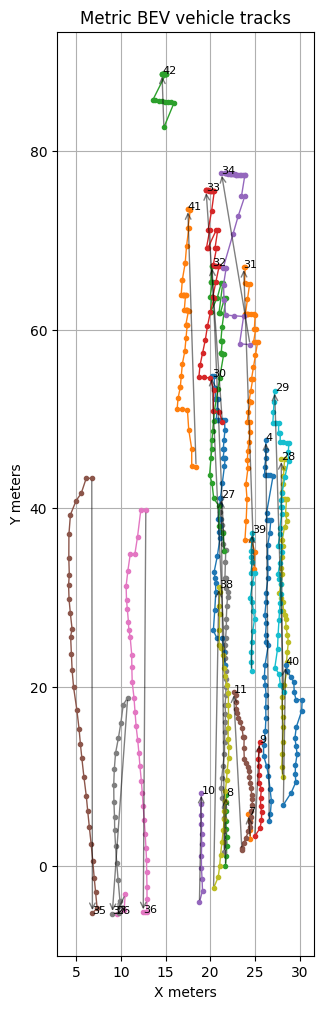

Saved metric BEV tracks: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/metric_bev_tracks.png
Saved track motion diagnostics: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/track_motion_diagnostics.csv


,track_id,num_points,first_frame,last_frame,dx_m,dy_m,x_span_m,y_span_m,mean_speed_mps,yaw_start_rad
0,4,40,0,39,-0.376580,42.616714,1.067730,42.616714,8.928539,1.570796
8,28,40,0,39,-0.156424,35.499295,1.003323,35.499295,7.394496,1.570796
21,41,40,0,39,-0.917526,28.755772,2.114712,28.755772,6.182233,1.570796
13,33,40,0,39,-1.818954,25.951939,2.624709,25.951939,6.646292,1.570796
12,32,40,0,39,-1.363003,31.923222,1.826740,31.923222,8.481773,1.570796
10,30,40,0,39,-1.483033,32.298159,1.505426,32.298159,6.934528,1.570796
9,29,40,0,39,-1.003381,33.727608,1.809527,33.727608,7.248199,1.570796
11,31,40,0,39,-1.168635,33.707485,1.557306,33.707485,7.304947,1.570796
7,27,40,0,39,-0.360095,39.652579,0.919674,39.652579,8.227104,1.570796
14,34,34,0,33,-3.201557,19.201405,3.201557,19.201405,5.763340,1.570796


In [8]:
#@title 7. Plot metric BEV tracks
fig_width = 8
fig_height = fig_width * BEV_HEIGHT / BEV_WIDTH
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

diagnostic_rows = []
for track_id, group in metric.groupby('track_id'):
    group = group.sort_values('frame_id')
    ax.plot(group['x_m'], group['y_m'], marker='o', linewidth=1, markersize=3)
    first = group.iloc[0]
    last = group.iloc[-1]
    ax.text(last['x_m'], last['y_m'], str(track_id), fontsize=8)
    ax.annotate('', xy=(last['x_m'], last['y_m']), xytext=(first['x_m'], first['y_m']), arrowprops=dict(arrowstyle='->', lw=1, alpha=0.5))
    diagnostic_rows.append({
        'track_id': int(track_id),
        'num_points': int(len(group)),
        'first_frame': int(first['frame_id']),
        'last_frame': int(last['frame_id']),
        'dx_m': float(last['x_m'] - first['x_m']),
        'dy_m': float(last['y_m'] - first['y_m']),
        'x_span_m': float(group['x_m'].max() - group['x_m'].min()),
        'y_span_m': float(group['y_m'].max() - group['y_m'].min()),
        'mean_speed_mps': float(group['speed_mps'].mean()),
        'yaw_start_rad': float(group['yaw_rad'].iloc[0]),
    })

track_motion_diagnostics = pd.DataFrame(diagnostic_rows)
diagnostics_path = NB04_DIR / 'track_motion_diagnostics.csv'
track_motion_diagnostics.to_csv(diagnostics_path, index=False)

ax.set_title('Metric BEV vehicle tracks')
ax.set_xlabel('X meters')
ax.set_ylabel('Y meters')
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

bev_metric_overlay_path = NB04_DIR / 'metric_bev_tracks.png'
plt.savefig(bev_metric_overlay_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved metric BEV tracks:', bev_metric_overlay_path)
print('Saved track motion diagnostics:', diagnostics_path)
display(track_motion_diagnostics.sort_values('num_points', ascending=False).head(30))


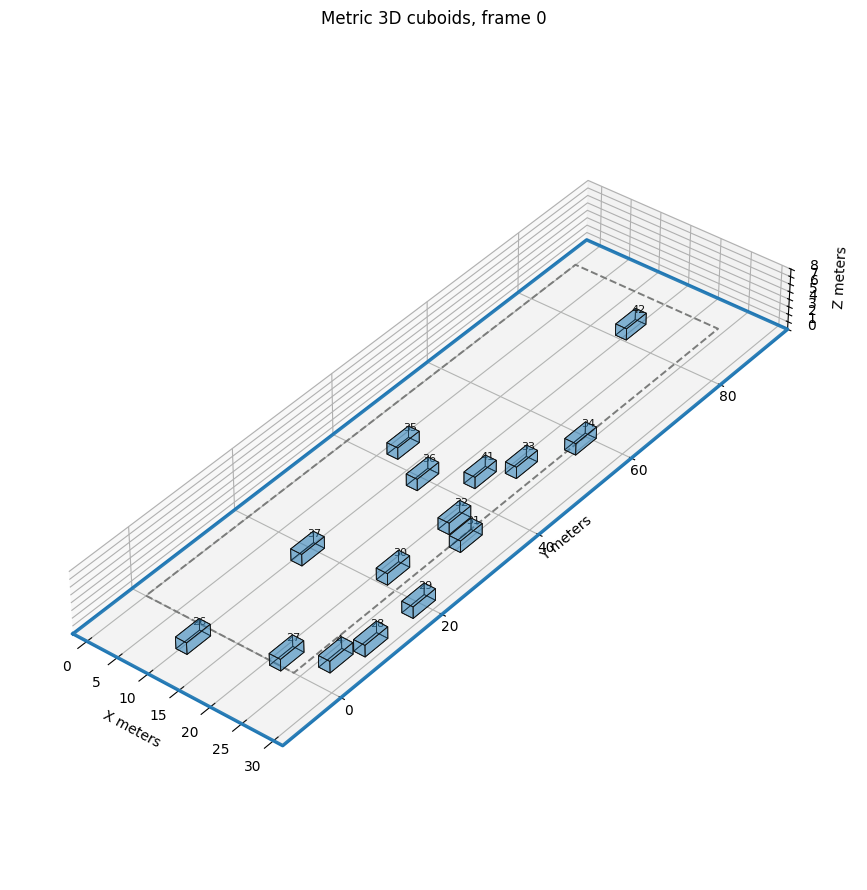

Saved 3D preview: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/metric_3d_cuboids_preview.png


In [9]:
#@title 8. 3D preview with metric cuboids
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def cuboid_vertices(cx, cy, cz, length, width, height, yaw):
    x = length / 2.0
    y = width / 2.0
    z = height / 2.0
    local = np.array([
        [-x, -y, -z], [ x, -y, -z], [ x,  y, -z], [-x,  y, -z],
        [-x, -y,  z], [ x, -y,  z], [ x,  y,  z], [-x,  y,  z],
    ], dtype=float)
    c = math.cos(yaw)
    s = math.sin(yaw)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=float)
    return local @ R.T + np.array([cx, cy, cz])

def cuboid_faces(verts):
    return [
        [verts[i] for i in [0, 1, 2, 3]],
        [verts[i] for i in [4, 5, 6, 7]],
        [verts[i] for i in [0, 1, 5, 4]],
        [verts[i] for i in [1, 2, 6, 5]],
        [verts[i] for i in [2, 3, 7, 6]],
        [verts[i] for i in [3, 0, 4, 7]],
    ]

PREVIEW_FRAME_ID = int(cuboids_df['frame_id'].min()) #@param {type:'integer'}
frame_df = cuboids_df[cuboids_df['frame_id'] == PREVIEW_FRAME_ID].copy()
if len(frame_df) == 0:
    raise ValueError('No cuboids for PREVIEW_FRAME_ID: ' + str(PREVIEW_FRAME_ID))

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

# Prefer the true metric calibration dimensions. The old BEV_WIDTH * meters_per_pixel
# can be narrower than the current metric coordinates and makes cars look outside.
road_w_m = float(ROAD_WIDTH_M) if 'ROAD_WIDTH_M' in globals() else float(BEV_WIDTH * meters_per_pixel)
road_h_m = float(ROAD_LENGTH_M) if 'ROAD_LENGTH_M' in globals() else float(BEV_HEIGHT * meters_per_pixel)

all_preview_verts = []
for _, row in frame_df.iterrows():
    all_preview_verts.append(cuboid_vertices(row['center_x_m'], row['center_y_m'], row['center_z_m'], row['length_m'], row['width_m'], row['height_m'], row['yaw_rad']))
all_preview_verts = np.vstack(all_preview_verts) if all_preview_verts else np.zeros((0, 3), dtype=float)

x_min = min(0.0, float(all_preview_verts[:, 0].min()) if len(all_preview_verts) else 0.0)
x_max = max(road_w_m, float(all_preview_verts[:, 0].max()) if len(all_preview_verts) else road_w_m)
y_min = min(0.0, float(all_preview_verts[:, 1].min()) if len(all_preview_verts) else 0.0)
y_max = max(road_h_m, float(all_preview_verts[:, 1].max()) if len(all_preview_verts) else road_h_m)
pad_x = max(2.0, 0.08 * (x_max - x_min))
pad_y = max(4.0, 0.06 * (y_max - y_min))
xlim_3d = (x_min - pad_x, x_max + pad_x)
ylim_3d = (y_min - pad_y, y_max + pad_y)

# Draw the rendered scene footprint plus the calibrated road footprint.
viewport_plane = [[
    (xlim_3d[0], ylim_3d[0], 0),
    (xlim_3d[1], ylim_3d[0], 0),
    (xlim_3d[1], ylim_3d[1], 0),
    (xlim_3d[0], ylim_3d[1], 0),
]]
ax.add_collection3d(Poly3DCollection(viewport_plane, alpha=0.08, facecolors='#dfe8df', edgecolors='none'))
ax.plot([xlim_3d[0], xlim_3d[1], xlim_3d[1], xlim_3d[0], xlim_3d[0]], [ylim_3d[0], ylim_3d[0], ylim_3d[1], ylim_3d[1], ylim_3d[0]], [0, 0, 0, 0, 0], linewidth=2.5, color='#1f77b4', label='rendered scene footprint')
ax.plot([0, road_w_m, road_w_m, 0, 0], [0, 0, road_h_m, road_h_m, 0], [0.03, 0.03, 0.03, 0.03, 0.03], linewidth=1.4, color='0.45', linestyle='--', label='calibrated road footprint')

for _, row in frame_df.iterrows():
    verts = cuboid_vertices(row['center_x_m'], row['center_y_m'], row['center_z_m'], row['length_m'], row['width_m'], row['height_m'], row['yaw_rad'])
    faces = cuboid_faces(verts)
    poly = Poly3DCollection(faces, alpha=0.35, linewidths=0.6, edgecolors='k')
    ax.add_collection3d(poly)
    ax.text(row['center_x_m'], row['center_y_m'], row['center_z_m'] + row['height_m'], str(int(row['track_id'])), fontsize=8)

ax.set_xlim(*xlim_3d)
ax.set_ylim(*ylim_3d)
ax.set_zlim(0, 8)
ax.set_xlabel('X meters')
ax.set_ylabel('Y meters')
ax.set_zlabel('Z meters')
ax.set_title('Metric 3D cuboids, frame ' + str(PREVIEW_FRAME_ID))
ax.view_init(elev=38, azim=-52)
ax.set_box_aspect((xlim_3d[1] - xlim_3d[0], ylim_3d[1] - ylim_3d[0], 10))
plt.tight_layout()
preview_path = NB04_DIR / 'metric_3d_cuboids_preview.png'
plt.savefig(preview_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved 3D preview:', preview_path)


In [10]:
#@title 9. Export simple OBJ scene for one frame
OBJ_FRAME_ID = PREVIEW_FRAME_ID #@param {type:'integer'}
obj_df = cuboids_df[cuboids_df['frame_id'] == OBJ_FRAME_ID].copy()
if len(obj_df) == 0:
    raise ValueError('No cuboids for OBJ_FRAME_ID: ' + str(OBJ_FRAME_ID))

obj_path = NB04_DIR / ('scene_frame_' + str(OBJ_FRAME_ID).zfill(6) + '.obj')
vertices = []
faces = []
road_w_m = BEV_WIDTH * meters_per_pixel
road_h_m = BEV_HEIGHT * meters_per_pixel
road_start = len(vertices) + 1
vertices.extend([(0, 0, 0), (road_w_m, 0, 0), (road_w_m, road_h_m, 0), (0, road_h_m, 0)])
faces.append((road_start, road_start + 1, road_start + 2, road_start + 3))

for _, row in obj_df.iterrows():
    verts = cuboid_vertices(row['center_x_m'], row['center_y_m'], row['center_z_m'], row['length_m'], row['width_m'], row['height_m'], row['yaw_rad'])
    start = len(vertices) + 1
    vertices.extend([tuple(v) for v in verts])
    for face_ids in [[0,1,2,3], [4,5,6,7], [0,1,5,4], [1,2,6,5], [2,3,7,6], [3,0,4,7]]:
        faces.append(tuple(start + i for i in face_ids))

nl = chr(10)
with open(obj_path, 'w') as f:
    f.write('# UAVDT metric cuboid scene' + nl)
    for v in vertices:
        f.write('v ' + str(v[0]) + ' ' + str(v[1]) + ' ' + str(v[2]) + nl)
    for face in faces:
        f.write('f ' + ' '.join(str(i) for i in face) + nl)

print('Saved OBJ scene:', obj_path)
print('Vertices:', len(vertices))
print('Faces:', len(faces))


Saved OBJ scene: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/scene_frame_000000.obj
Vertices: 124
Faces: 91


In [11]:
#@title 10. Export dynamic scene JSON
scene_json = {
    'coordinate_system': {
        'x': 'right in BEV, meters',
        'y': 'forward/up in BEV, meters',
        'z': 'up, meters',
    },
    'calibration': calibration_json,
    'source_files': {
        'homography_json': str(homography_path),
        'tracks_csv': str(tracks_path),
    },
    'vehicle_dimensions_default_m': {
        k: {'length': v[0], 'width': v[1], 'height': v[2]} for k, v in DEFAULT_DIMS.items()
    },
    'frames': [],
}

for frame_id, group in cuboids_df.groupby('frame_id'):
    frame_record = {
        'frame_id': int(frame_id),
        'time_s': float(frame_id / FPS),
        'vehicles': [],
    }
    for _, row in group.iterrows():
        frame_record['vehicles'].append({
            'track_id': int(row['track_id']),
            'class_name': row['class_name'],
            'center_m': [float(row['center_x_m']), float(row['center_y_m']), float(row['center_z_m'])],
            'size_m': [float(row['length_m']), float(row['width_m']), float(row['height_m'])],
            'yaw_rad': float(row['yaw_rad']),
            'speed_mps': float(row['speed_mps']),
        })
    scene_json['frames'].append(frame_record)

scene_json_path = NB04_DIR / 'dynamic_metric_scene.json'
with open(scene_json_path, 'w') as f:
    json.dump(scene_json, f, indent=2)

print('Saved dynamic metric scene:', scene_json_path)
print('Frames:', len(scene_json['frames']))
print('Objects:', sum(len(fr['vehicles']) for fr in scene_json['frames']))


Saved dynamic metric scene: /Users/vash/Dev/ResearchLab/Work/Drone3D/local_uav_bev_project/work/notebook_04_metric_scene_export/dynamic_metric_scene.json
Frames: 40
Objects: 632


## Next

After this notebook, run Notebook 05 to create dynamic videos and interactive visualizations from:

- `vehicle_tracks_metric.csv`
- `vehicle_cuboids_metric.csv`
- `dynamic_metric_scene.json`
